In [1]:
# ライブラリーのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# データの読み込み
data_train = pd.read_csv('data/train.csv')
data_test = pd.read_csv('data/test.csv')
data_submission = pd.read_csv('data/sample_submission.csv')

In [3]:
data_train.tail(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
594184,594184,Female,1,Yes,No,40,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,103.90,4108.15,Yes
594185,594185,Male,0,Yes,No,39,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,3452.55,Yes
594186,594186,Female,1,No,No,29,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),95.40,2698.35,No
594187,594187,Male,0,Yes,Yes,3,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Electronic check,80.45,244.45,Yes
594188,594188,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),20.25,669.05,No
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No
594193,594193,Female,1,Yes,No,2,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.55,108.05,Yes


In [4]:
data_test.head(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65
5,594199,Male,0,No,No,24,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.95,1406.20
6,594200,Female,0,No,No,1,Yes,No,Fiber optic,Yes,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,78.60,78.60
7,594201,Female,0,No,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),60.35,3825.20
8,594202,Female,0,Yes,No,55,Yes,Yes,Fiber optic,No,No,No,No,No,No,One year,No,Credit card (automatic),75.45,4459.15
9,594203,Female,0,No,No,50,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.85,4533.90


In [5]:
data_train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [6]:
data_submission.head(10)

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0
5,594199,0
6,594200,0
7,594201,0
8,594202,0
9,594203,0


In [7]:
# ydata-profilingのインストール
!pip install ydata-profiling
from ydata_profiling import ProfileReport

data_train.profile_report()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:03<00:00,  5.77it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

## 各々の特徴量と、目的の変数（Churn）との関係性を確認

In [9]:
# 各々の特徴量（genderからTotalCharges）と、目的の変数（Churn）との関係性を確認するためのグラフを作成
for column in data_train.columns[1:]:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=column, hue='Churn', data=data_train)
    plt.title(f'{column} vs Churn')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='Churn', loc='upper right')
    plt.show()



/var/folders/lj/rcsyr8rj4gl5yjh1p78gq8rr0000gn/T/ipykernel_99884/2923758847.py:9: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plt.show()
/var/folders/lj/rcsyr8rj4gl5yjh1p78gq8rr0000gn/T/ipykernel_99884/2923758847.py:9: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plt.show()
/var/folders/lj/rcsyr8rj4gl5yjh1p78gq8rr0000gn/T/ipykernel_99884/2923758847.py:9: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plt.show()
/var/folders/lj/rcsyr8rj4gl5yjh1p78gq8rr0000gn/T/ipykernel_99884/2923758847.py:9: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plt.show()
/var/folders/lj/rcsyr8rj4gl5yjh1p78gq8rr0000gn/T/ipykern

<Axes: xlabel='Sex', ylabel='count'>

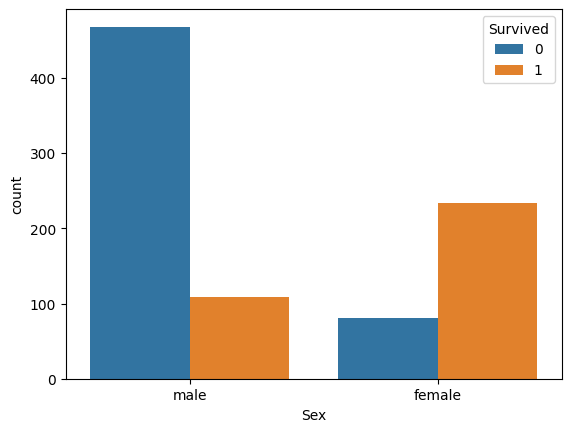

In [ ]:
# Sexとの関係
sns.countplot(x = 'Sex', hue = 'Survived', data = data_train)
# 女性客の生存割合が高いな。優先的に女性が救助されたのかも？

<Axes: xlabel='Age', ylabel='count'>

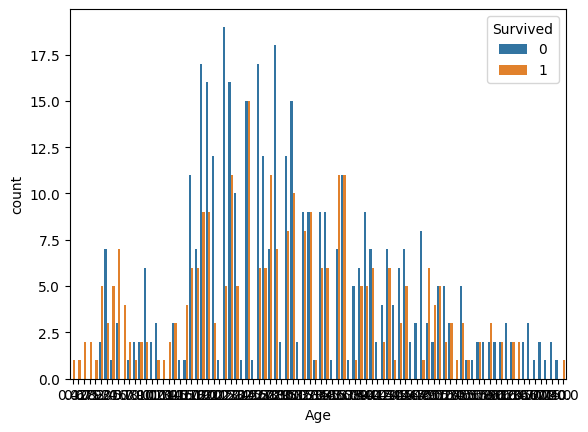

In [ ]:
# Ageとの関係
sns.countplot(x = 'Age', hue = 'Survived', data = data_train)
# 見づらいな。ヒストグラムで、階層の幅広げて表示するか

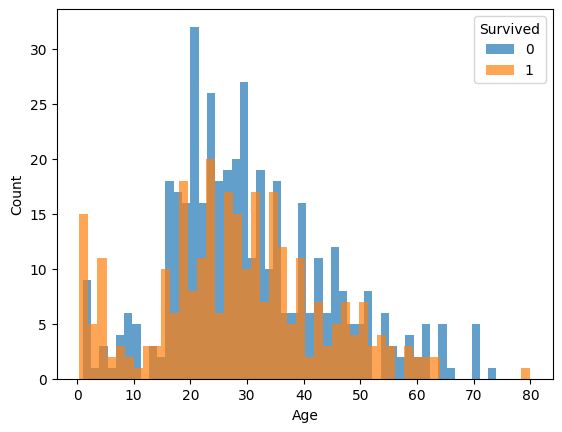

In [ ]:
# ヒストグラムで表示
# loc 条件を満たす行のみ抜き出す
# dropna() データのない行は削除する
# bins 棒の数　これに合わせてAgeの幅が自動で設定される
# alpha グラフの透明度、重ねて表示するので。ちなみにbins固定で幅は自動なので重ならない

plt.hist(data_train.loc[data_train["Survived"] == 0, 'Age'].dropna(),bins = 50, alpha = 0.7, label = 0) # ageごとにSurvivedの値で取得
plt.hist(data_train.loc[data_train["Survived"] == 1, 'Age'].dropna(),bins = 50, alpha = 0.7, label = 1) # ageごとにSurvivedの値で取得
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title = 'Survived')

# やはり5、6歳までの生存率が高いので、優先的に救助されたと考えられる。

<Axes: xlabel='SibSp', ylabel='count'>

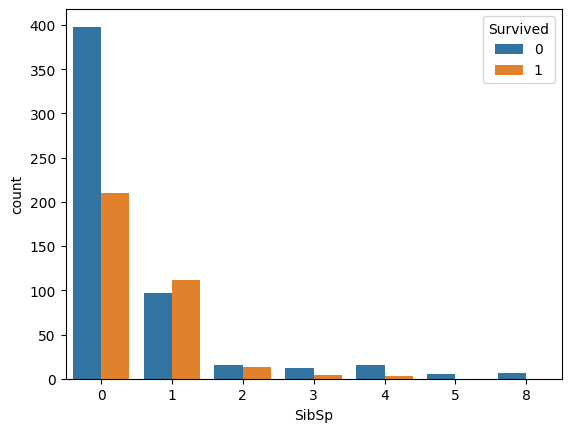

In [ ]:
# SibSpとの関係
sns.countplot(x = 'SibSp', hue = 'Survived', data = data_train)
# 単純に、人数が増えると生存率が下がる
# 兄弟姉妹や配偶者が一人、二人いる場合の方が、生存率が同等若しくは高い。
# でも3人や4人、それ以上いる場合は、生存率が低い。心中？人数が多いと生存にマイナスに働く？
# 一人もいない場合は生存率が低い。独り身だと生存にマイナスに働く？

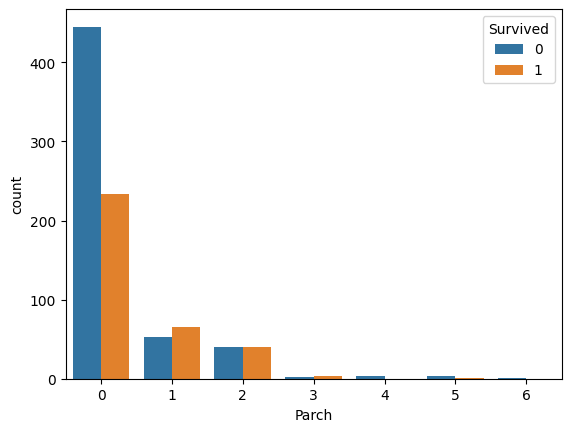

In [ ]:
# Parchとの関係
sns.countplot(x = 'Parch', hue = 'Survived', data = data_train)
# 同じく、親や子が一人、二人いる場合の方が、生存率が同等若しくは高い。
# でも3人や4人、それ以上いる場合は、生存率が低い。心中？
# 一人もいない場合は生存率が低い。
# SibSpとParchそもそも分ける意味がない？合わせた特徴量で見るとなにか別のヒントが得られるかも？

# 凡例の右上固定表示
plt.legend(loc = 'upper right', title = 'Survived')

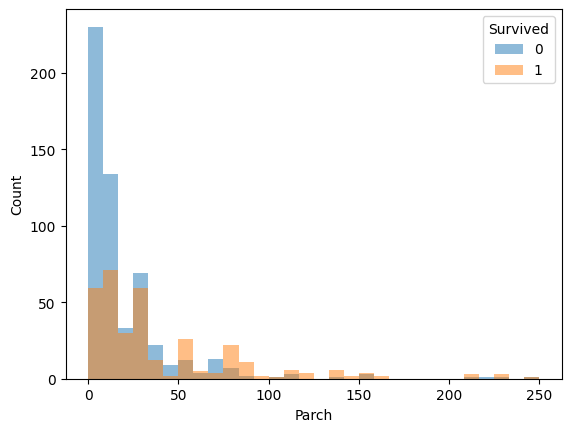

In [ ]:
# Fare（運賃）との関係
# 種類が多いので、ヒストグラムで作成
# 範囲はrangeで指定

plt.hist(data_train.loc[data_train["Survived"] == 0, 'Fare'].dropna(), range = (0,250), bins = 30, alpha = 0.5, label = 0) # ageごとにSurvivedの値で取得
plt.hist(data_train.loc[data_train["Survived"] == 1, 'Fare'].dropna(),range = (0,250), bins = 30, alpha = 0.5, label = 1) # ageごとにSurvivedの値で取得
plt.xlabel('Parch')
plt.ylabel('Count')
plt.legend(title = 'Survived')

# 運賃が安い方が生存率が低い、高い運賃払ったんだから先に救助？
# どんな特徴量がどれだけ生存率にプラスあるいはマイナスに寄与しているのか？

<Axes: xlabel='Embarked', ylabel='count'>

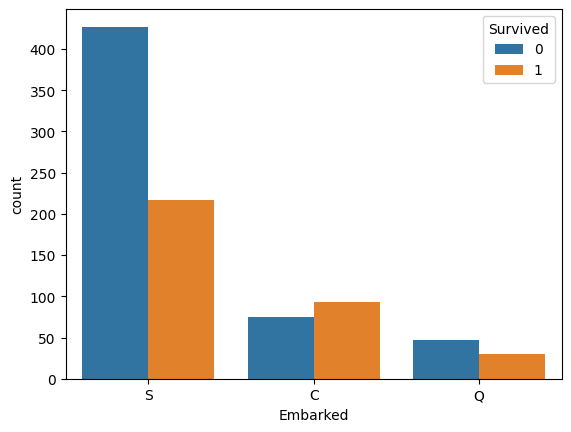

In [ ]:
# Embarkedとの関係
sns.countplot(x = 'Embarked', hue = 'Survived', data = data_train)
# Sからの乗船客が生存率が低い。乗船した地域によって客層が異なった？子供が多かった？富裕層が多かった？

# どんなことでもいいからいろんなことを思いつくことが大事。

## 特徴量エンジニアリング
文字列を数値に置き換え
欠損値の扱い

In [ ]:
# 教師用データとテストデータ、双方にエンジニアリングを行うため、一旦一つに結合する。
    # データの中身を変更していく際にテストデータには、教師データに実行した変更が反映されてない状態になるから

# 結合は concatでリスト指定。教師、テストで縦連結。
data_all = pd.concat([data_train, data_test], sort = False) # 列の順番は変えずにただ結合してください

data_all


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [19]:
# 各特徴量の欠損値の数を確認
# データの欠損は　isnull
# TestデータはSurvivedがないので欠損値扱い

data_all.isnull().sum()

# Null418件がテストデータの数を意味する

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [20]:
# Sexを数値に置き換え
data_all['Sex'].replace(['male', 'female'], [0, 1], inplace = True) # 変更後の結果をでーたふれ

/tmp/ipykernel_17/851876621.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_all['Sex'].replace(['male', 'female'], [0, 1], inplace = True) # 変更後の結果をでーたふれ
/tmp/ipykernel_17/851876621.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Sex'].replace(['male', 'female'], [0, 1], inpla

In [21]:
data_all.head()
# Sexの特徴量が数値化された

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


In [22]:
# Embarkedの欠損値を補完する、数値に置き換える
    # 2件でも欠損があればアルゴリズムは適応できないから
    # 本来なら欠損値を補完する方法を検討するが、今回は2件だし一番多いSで補完
data_all['Embarked'].fillna('S', inplace = True)
data_all['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2], inplace = True) # 変更後の結果をでーたふれ
data_all.head(900)

# One-Hotエンコーディング
    # Embarkedを1、2、3で置き換えると、その大きさに意味があるものとアルゴリズムに勘違いされてしまう場合がある。ので、データの数分、列数が増えるので、データサイズが大きくなる。
    # カテゴリ指定を予めできるものもあり、数値特有の大きさや順番を考慮しないものもある

/tmp/ipykernel_17/2239516266.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_all['Embarked'].fillna('S', inplace = True)
/tmp/ipykernel_17/2239516266.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2], inplace = True) # 変更後の結果をでーたふれ


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4,896,NaN,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,0
5,897,NaN,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NaN,0
6,898,NaN,3,"Connolly, Miss. Kate",1,30.0,0,0,330972,7.6292,NaN,2
7,899,NaN,2,"Caldwell, Mr. Albert Francis",0,26.0,1,1,248738,29.0000,NaN,0


In [23]:
data_all.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          0
dtype: int64

In [24]:
# Fareは平均で補完, Ageも平均で補完（Ageはそもそも欠損が多いので補完するかどうかを検討した方がいい）
data_all['Fare'].fillna(np.mean(data_all['Fare']), inplace = True)
data_all['Age'].fillna(np.mean(data_all['Age']), inplace = True)
data_all.head(900)

/tmp/ipykernel_17/828574674.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_all['Fare'].fillna(np.mean(data_all['Fare']), inplace = True)
/tmp/ipykernel_17/828574674.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4,896,NaN,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,0
5,897,NaN,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NaN,0
6,898,NaN,3,"Connolly, Miss. Kate",1,30.0,0,0,330972,7.6292,NaN,2
7,899,NaN,2,"Caldwell, Mr. Albert Francis",0,26.0,1,1,248738,29.0000,NaN,0


In [25]:
# 影響のないあるいは少なそうな特徴量については一旦削除。
# drop 行または列で削除する関数。axis - 1で列方向
drop_colums = ['PassengerId', 'Name', 'Parch', 'SibSp', 'Ticket', 'Cabin']
data_all.drop(drop_colums, axis = 1, inplace = True)
data_all.isnull().sum()
# まあこれでひとまず欠損値はなくなった
# SibSpやらParchは消していいのか？

Survived    418
Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
dtype: int64

In [ ]:
# 結合したデータを、再度、教師データと、テストデータに分ける
# len関数は、行数を返してくれる。スライスで該当行を抜き出し。
# 先頭行から教師データの件数だけ抜き出すのと、その一個下のデータから
data_train = data_all[:len(data_train)]
data_test = data_all[len(data_train):]

## モデル作成

In [ ]:
# アルゴリズムに投入。多くの場合別々に投入するのでそのために特徴量と目的変数を分離、x,yと頭文字をつけておく
y_data_train = data_train['Survived']
x_data_train = data_train.drop('Survived', axis = 1) # 説明変数を格納、dropで目的変数は削除。axis = 1は列を削除の意味
x_data_test = data_test.drop('Survived', axis = 1) # testデータにはSurvivedがなかったが、結合で列が発生したので消しておく。

In [ ]:
# Random forest アルゴリズムをインポート
    # アルゴリズム…数値に対する演算をまとめたもの。決定木をベースに拡張。一つの特徴量ごとに閾値（条件判定の結果の値）を決めて、処理を分岐させてこの分岐ならこの予測値、を出す。
    # ランダムフォレストは複数の学習機の結果をもとに予測を出す。例えばGenderを最初にした決定木の予測では不十分なので、複数の決定木から精度を高める。例えば多数決を取るなど。
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators = 100, max_depth = 2, random_state = 0) 
# 引数として条件を格納、ensambleする決定木の本数、乱数のシード（指定で実行結果が毎回同じになる。0に意味はない。同じ数字を振ったものが同じ結果になる）
# 分岐の層が少ないと感じるかもしれないが、必要ない条件で分岐をすることがいいとは限らない。処理に時間もかかる。とはいえ精査は必要。

# 教師データに適用して、学習させる
clf.fit(x_data_train, y_data_train) # 説明変数と目的変数を別の変数として指定

RandomForestClassifier(max_depth=2, random_state=0)

In [29]:
y_data_pred = clf.predict(x_data_test)# 学習したclfに対して、引数にはテストデータを指定
# predictの閾値はデフォルト0.5。それ未満を0、以上を1として丸めて返す。本来0〜1の確率として返す。生存確率が高い0.5以上を生存、未満を0の死亡と返す。
y_data_pred
# Survivedに対する予測結果。テストデータとして与えた先頭行の乗船客から順に予測が行われリストが返される。

array([0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0.,
       1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1.,
       0., 1., 0., 1., 1.

## Submit

In [30]:
# 予測結果をSubmit用のCSVファイルとして作成
submit = data_gender_submission # 冒頭で作った変数。提出用CSVのこと。めんどいのでsubmitとする。
submit['Survived'] = list(map(int, y_data_pred)) 
# map 指定した要素に対して、適用したい関数（int）を適用できる関数。予測結果を整数型にして提出フォーマットに合わせるため。
# リストで提出用ファイルに.
submit.to_csv('randomforest_submit.csv', index = False) # 出力ファイル名,index番号は出力しない